<a href="https://colab.research.google.com/github/MelvH/2022_personal_homepage/blob/main/notebooks/participant_distance_metrics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mining Distance Metrics Workshop Lab

## Scenario

You are part of a mining operations analytics team reviewing equipment sensor readings from different areas of a mine site.  
Each observation represents a machine reading with four measured features:

- **temperature**
- **vibration**
- **pressure**
- **humidity**

The operations team wants to answer practical questions such as:

- Which machines appear to be operating in a similar way?
- Which readings look quite different and may need review?
- How does the definition of "similar" change depending on the metric we choose?

In this activity, you will use distance metrics to compare sensor readings and connect those results to simple machine learning tasks.

## Key ideas

This lab introduces the following ideas:

- an **observation** is one row of data
- a **feature** is one measured column
- a **distance metric** gives a numerical way to compare two observations
- different metrics capture different meanings of similarity
- distance-based comparisons are often used in **anomaly review**, **clustering**, and **nearest-neighbour** style analysis

## Learning goals

By the end of the lab, you should be able to:

1. load a sensor dataset into a notebook
2. inspect rows, columns, and summary statistics
3. compare two observations using Euclidean distance, Manhattan distance, and cosine similarity
4. explain what each metric is emphasising
5. create a distance matrix and identify similar rows
6. connect these ideas to mining use cases


## How to use this notebook

Follow the notebook from top to bottom.

### Running cells

- Click on a cell.
- Press **Shift + Enter** to run it.
- Wait for the output to appear before moving to the next cell.

### How to work through the lab

1. Read the explanation above each code cell.
2. Run the code cell.
3. Look at the output and compare it to the explanation.
4. Complete the checkpoint tasks where prompted.
5. Use the worked solution cells only after attempting each task yourself.

### If something goes wrong

- Re-run the current cell.
- Check whether you already ran the earlier setup cells.
- Make sure the dataset path is correct.
- If needed, restart the notebook kernel/runtime and run all cells again from the top.


## 1) Set up the environment


In [1]:
# Import the libraries used in this workshop.
# Each library gives us a set of tools for a different kind of task.

import pandas as pd               # Work with tabular data such as CSV files
import numpy as np                # Perform numerical calculations with arrays
import matplotlib.pyplot as plt   # Create charts and visualisations

# Import distance and similarity functions from scikit-learn.
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

print("Environment ready ✅")


Environment ready ✅


### Why we do this

Before we can analyse the data, we need to load the Python tools used in the notebook.

- **pandas** handles data tables
- **numpy** supports calculations
- **matplotlib** draws charts
- **scikit-learn** provides distance and similarity utilities


## 2) Load the dataset


In [2]:
# Load the mining sensor dataset from the repository.
# The relative path works when the notebook is kept inside the notebooks/ folder.

DATA_URL = "https://raw.githubusercontent.com/albert-axi/mining-distance-metrics-workshop/main/data/sample_mining_sensors.csv"
df = pd.read_csv(DATA_URL)

# Display the first few rows so we can see what the dataset looks like.
df.head()


,reading_id,site_zone,equipment_type,temperature,vibration,pressure,humidity,state_label
0,R001,Crusher,Crusher Feed,74.13,1.99,106.74,48.45,Normal
1,R002,Conveyor,Pump,64.72,3.20,119.97,39.76,Normal
2,R003,Haulage,Crusher Feed,77.25,3.65,120.42,34.71,Normal
3,R004,Mill,Pump,78.58,4.03,132.95,46.85,Normal
4,R005,Crusher,Conveyor Motor,58.34,4.14,127.19,41.43,Normal


### What this cell is doing

This code reads a CSV file into a pandas **DataFrame**, which behaves like a spreadsheet table in Python.

We then display the first five rows so we can check:

- what the columns are called
- whether the data loaded correctly
- what each record looks like


## 3) Inspect the data


In [3]:
# Check the number of rows and columns in the dataset.
# The result is returned as: (rows, columns)

df.shape


(60, 8)

In [4]:
# Show the column names.
# This helps us identify which fields are useful for distance calculations.

df.columns.tolist()


['reading_id',
 'site_zone',
 'equipment_type',
 'temperature',
 'vibration',
 'pressure',
 'humidity',
 'state_label']

In [6]:
# Summarise the numeric features.
# This gives us count, average, spread, minimum, and maximum values.

df.describe()


,temperature,vibration,pressure,humidity
count,60.000000,60.000000,60.000000,60.000000
mean,73.389833,3.470667,116.406000,38.474000
std,6.972511,0.921430,12.359082,7.935942
min,58.340000,1.980000,90.960000,20.820000
25%,68.635000,3.007500,107.315000,33.145000
50%,73.550000,3.325000,116.270000,38.105000
75%,77.212500,3.932500,122.647500,43.150000
max,96.560000,7.070000,150.050000,58.140000


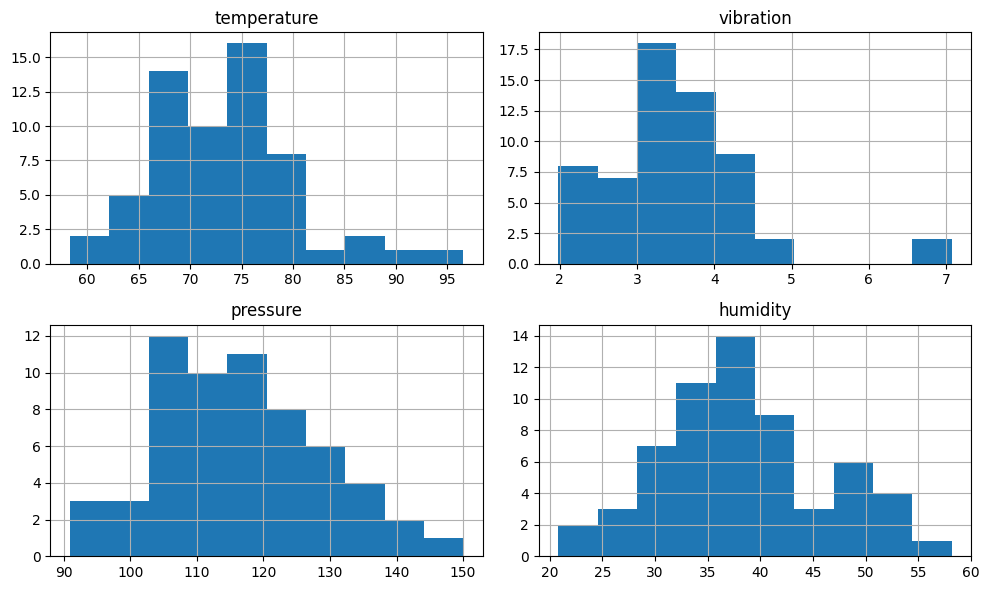

In [7]:
# Create histograms for the four sensor features.
# A histogram helps us see how values are distributed.

df[["temperature", "vibration", "pressure", "humidity"]].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


### Why inspection matters

We inspect the data before comparing records because distance metrics depend on the values in each feature.

Questions to think about:

- Are some features much larger in scale than others?
- Are some readings unusually high or low?
- Do the features appear tightly grouped or widely spread?

These questions matter because they affect how similarity is measured.


## 4) Select two sensor readings to compare


In [8]:
# Choose the features we want to compare.
# These are the numerical measurements that represent each sensor reading.

features = ["temperature", "vibration", "pressure", "humidity"]

# Select row 0 and row 1 from the dataset.
# .to_numpy() converts the selected values into NumPy arrays,
# which are easier to use in mathematical calculations.

sensor_a = df.loc[0, features].to_numpy()
sensor_b = df.loc[1, features].to_numpy()

print("Sensor A values:")
print(sensor_a)
print()
print("Sensor B values:")
print(sensor_b)


Sensor A values:
[np.float64(74.13) np.float64(1.99) np.float64(106.74) np.float64(48.45)]

Sensor B values:
[np.float64(64.72) np.float64(3.2) np.float64(119.97) np.float64(39.76)]


In [9]:
# Show the same two records in table form.
# This is often easier to read than looking at raw arrays.

df.loc[[0, 1], ["reading_id", "site_zone", "equipment_type"] + features]


,reading_id,site_zone,equipment_type,temperature,vibration,pressure,humidity
0,R001,Crusher,Crusher Feed,74.13,1.99,106.74,48.45
1,R002,Conveyor,Pump,64.72,3.20,119.97,39.76


### Why we start with two rows

Starting with only two rows makes the ideas easier to understand.

Once you know how two observations are compared, you can extend the same logic to all rows in the dataset.


## 5) Euclidean distance


**Plain-language idea:** Euclidean distance is the straight-line distance between two points.

**Mining interpretation:** Use this when you care about the overall size of the difference across all sensor features.


In [10]:
# Calculate Euclidean distance between the two selected sensor readings.
#
# Step by step:
# 1. sensor_a - sensor_b calculates the feature-by-feature differences.
# 2. np.linalg.norm(...) combines those differences into a single distance value.
#
# Interpretation:
# - smaller value -> the two readings are more similar
# - larger value  -> the two readings are more different

euclid = np.linalg.norm(sensor_a - sensor_b)
print("Euclidean distance:", round(float(euclid), 4))


Euclidean distance: 18.4543


## 6) Manhattan distance


**Plain-language idea:** Manhattan distance adds the absolute difference across each feature.

**Mining interpretation:** This can be useful when you want to treat each feature difference as a separate step and then total them.


In [11]:
# Calculate Manhattan distance.
#
# Step by step:
# 1. sensor_a - sensor_b finds the difference for each feature.
# 2. np.abs(...) converts every difference to a positive value.
# 3. np.sum(...) adds those values together.

manhattan = np.sum(np.abs(sensor_a - sensor_b))
print("Manhattan distance:", round(float(manhattan), 4))


Manhattan distance: 32.54


## 7) Cosine similarity


**Plain-language idea:** Cosine similarity compares the direction of two vectors rather than their overall size.

**Mining interpretation:** This is useful when the pattern across features matters more than the raw magnitude.


In [12]:
# Calculate cosine similarity.
#
# cosine_similarity expects 2D inputs, so each sensor vector is wrapped in [ ].
#
# Interpretation:
# - closer to 1  -> very similar direction/pattern
# - closer to 0  -> weak similarity
# - closer to -1 -> opposite direction

cos = cosine_similarity([sensor_a], [sensor_b])[0, 0]
print("Cosine similarity:", round(float(cos), 4))


Cosine similarity: 0.9916


### Checkpoint 1

In your own words, answer these questions:

1. Which metric says the two readings are most similar? - Cosine
2. Which metric focuses on absolute size of difference? - Euc
3. Which metric focuses more on pattern than magnitude? - Cosine

Add your answers in a new Markdown cell before moving on.


## 8) Build a distance matrix


In [13]:
# Convert the selected feature columns into a numeric matrix.
# Each row is one observation and each column is one feature.

X = df[features].to_numpy()

# Compute the Euclidean distance between every pair of rows.
# The result is a square matrix:
# - row i compared with row j
# - column j compared with row i

dist_matrix = euclidean_distances(X)

print("Distance matrix shape:", dist_matrix.shape)
pd.DataFrame(dist_matrix).head()


Distance matrix shape: (60, 60)


,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
0,0.000000,18.454300,19.708374,26.711200,26.859440,19.120999,28.847662,20.818228,24.723214,8.727434,...,22.609098,22.363001,15.970654,4.970855,17.456222,21.532972,40.031685,19.475952,23.105921,21.129191
1,18.454300,0.000000,13.524363,20.286375,9.823711,10.914587,16.324521,19.643202,38.601641,16.754137,...,18.774874,13.708165,7.598539,18.092988,18.182923,7.536146,24.995324,18.006046,10.979162,15.331631
2,19.708374,13.524363,0.000000,17.501251,21.185361,21.256223,15.133446,18.401266,32.525997,23.606205,...,13.188302,2.994361,18.110146,21.873642,18.734506,9.945315,21.633090,5.617535,13.062817,1.974513
3,26.711200,20.286375,17.501251,0.000000,21.730709,19.488366,9.427014,34.809051,44.282408,28.443307,...,30.563856,17.028975,26.847037,29.833642,33.981176,22.173667,27.494359,17.097166,26.944532,17.647286
4,26.859440,9.823711,21.185361,21.730709,0.000000,11.259827,16.254067,28.340993,48.183335,23.043980,...,27.272268,20.297175,14.680760,26.206818,27.095819,14.623618,25.089087,25.685338,17.634480,22.670787


### What to notice

- The matrix is square because every row is compared with every other row.
- The diagonal is 0 because each row has zero distance from itself.
- Smaller off-diagonal values indicate more similar observations.


## 9) Find the most similar pair in a subset


In [14]:
# Use only the first 25 rows so the example stays easy to inspect.
subset = df.head(25)[features].to_numpy()

# Calculate Euclidean distances within the subset.
d = euclidean_distances(subset)

# Ignore self-comparisons by replacing the diagonal with infinity.
# This prevents a row from being selected as the closest match to itself.
np.fill_diagonal(d, np.inf)

# Find the smallest remaining value in the matrix.
i, j = np.unravel_index(np.argmin(d), d.shape)

print(f"Closest pair in the first 25 rows: row {i} and row {j}")
print(f"Euclidean distance: {d[i, j]:.4f}")


Closest pair in the first 25 rows: row 9 and row 21
Euclidean distance: 2.4297


In [15]:
# Display the two most similar rows that were found.

df.loc[[i, j], ["reading_id", "site_zone", "equipment_type"] + features]


,reading_id,site_zone,equipment_type,temperature,vibration,pressure,humidity
9,R010,Mill,Excavator,66.03,3.33,107.81,51.21
21,R022,Crusher,Conveyor Motor,67.23,2.90,107.12,49.26


### Why we replace the diagonal

Every row is identical to itself, so the diagonal entries are all zero.

If we left those zeros in place, the algorithm would always say a row is most similar to itself, which is not helpful when we are trying to compare different readings.


## 10) Visualise two features


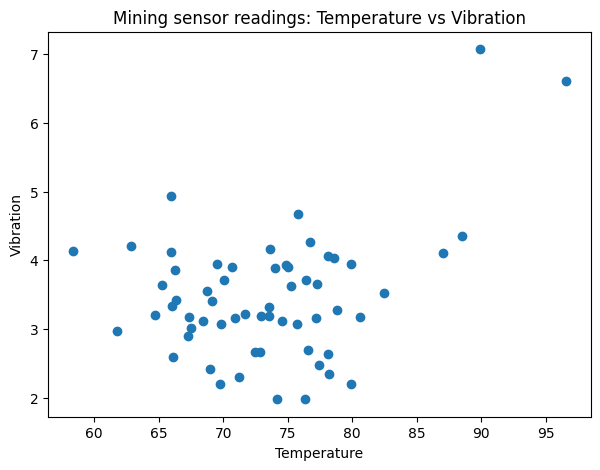

In [16]:
# Plot temperature against vibration.
# Each point represents one sensor reading.

plt.figure(figsize=(7, 5))
plt.scatter(df["temperature"], df["vibration"])
plt.xlabel("Temperature")
plt.ylabel("Vibration")
plt.title("Mining sensor readings: Temperature vs Vibration")
plt.show()


### What this chart helps us do

The scatter plot gives a visual way to think about similarity.

You can look for:

- points that sit close together
- points that sit far away from the main group
- possible unusual readings that may deserve investigation


## 11) Guided practice task


### Task

Using the **first 10 rows** of the dataset:

1. compute the cosine similarity matrix
2. ignore the diagonal so a row is not matched with itself
3. find the pair with the **highest** cosine similarity
4. plot the feature values for that pair side by side

Try to complete the cell below before opening the worked solution.


Closest pair row = 2 and column = 7
Cosine similarity score: 0.9997


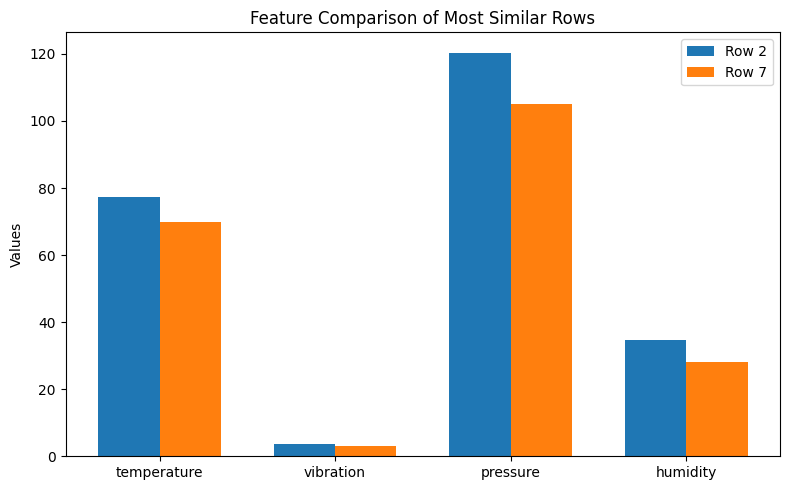

In [20]:
# Guided practice: complete the TODO steps.

subset = df.head(10)[features].to_numpy()

# Step 1: compare every row with every other row using cosine similarity
cos_m = cosine_similarity(subset)

# Step 2: ignore self-comparisons
# TODO: replace the diagonal values with -np.inf
np.fill_diagonal(cos_m, -np.inf)


# Step 3: find the indices of the highest similarity value
# TODO: use np.unravel_index and np.argmax
i, j = np.unravel_index(np.argmax(cos_m), cos_m.shape)

# Step 4: display the row numbers and similarity score
# TODO: print the pair and the score
print(f"Closest pair row = {i} and column = {j}")
print(f"Cosine similarity score: {cos_m[i, j]:.4f}")

# Step 5: plot the two rows on a bar chart
# TODO: create a bar chart that compares the feature values

x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, subset[i], width, label=f'Row {i}')
rects2 = ax.bar(x + width/2, subset[j], width, label=f'Row {j}')

ax.set_ylabel('Values')
ax.set_title('Feature Comparison of Most Similar Rows')
ax.set_xticks(x)
ax.set_xticklabels(features)
ax.legend()

plt.tight_layout()
plt.show()

### Checkpoint 2

Before you reveal the solution, explain why the cosine similarity task searches for the **largest** value rather than the smallest one.


Cosine similarity is based off the dot product of the two datasets over the multiple of the magnitude of the two sets.

It tends to 1 where that indicates that there is the closest match.

Cosine similarity calculates the cosine of the angle between two multi-dimensional vectors. The formula divides the dot product of the datasets by the product of their magnitudes, bounding the output strictly between -1 and 1.

We search for the largest value (closest to 1) because a cosine of 1 means the angle between the vectors is 0 degrees, indicating they point in the exact same direction and share identical patterns. Conversely, smaller values mean the vectors are unrelated (0) or completely opposite (-1).


## 12) Worked solution


Most similar pair by cosine similarity in the first 10 rows: row 2 and row 7
Cosine similarity: 0.9997


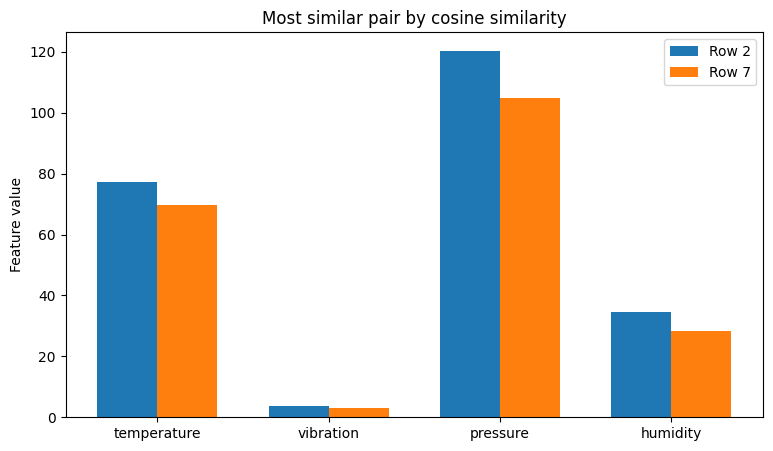

In [21]:
# Worked solution for the guided practice task.

subset = df.head(10)[features].to_numpy()
cos_m = cosine_similarity(subset)

# Ignore self-comparisons by assigning a very small placeholder value.
np.fill_diagonal(cos_m, -np.inf)

# Find the location of the highest cosine similarity.
i, j = np.unravel_index(np.argmax(cos_m), cos_m.shape)

print(f"Most similar pair by cosine similarity in the first 10 rows: row {i} and row {j}")
print(f"Cosine similarity: {cos_m[i, j]:.4f}")

# Plot the feature values side by side.
x = np.arange(len(features))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, subset[i], width=width, label=f"Row {i}")
plt.bar(x + width/2, subset[j], width=width, label=f"Row {j}")
plt.xticks(x, features)
plt.ylabel("Feature value")
plt.title("Most similar pair by cosine similarity")
plt.legend()
plt.show()


## 13) Optional extension: simple clustering


In [22]:
# K-Means is a clustering algorithm that groups observations into clusters.
# It uses distances to decide which rows are most alike.

from sklearn.cluster import KMeans

X = df[features].to_numpy()

# Create a model with 3 clusters.
# random_state=42 makes the result repeatable.
# n_init='auto' controls how many starting configurations are tested.
kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")

# fit_predict trains the model and returns the assigned cluster for each row.
clusters = kmeans.fit_predict(X)

df["cluster"] = clusters
df[["reading_id", "site_zone", "equipment_type", "cluster"] + features].head()


,reading_id,site_zone,equipment_type,cluster,temperature,vibration,pressure,humidity
0,R001,Crusher,Crusher Feed,0,74.13,1.99,106.74,48.45
1,R002,Conveyor,Pump,2,64.72,3.20,119.97,39.76
2,R003,Haulage,Crusher Feed,1,77.25,3.65,120.42,34.71
3,R004,Mill,Pump,2,78.58,4.03,132.95,46.85
4,R005,Crusher,Conveyor Motor,2,58.34,4.14,127.19,41.43


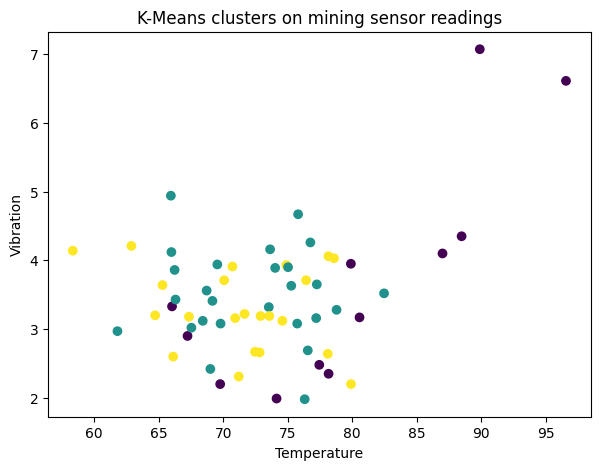

In [23]:
# Visualise the clusters using temperature and vibration.

plt.figure(figsize=(7, 5))
plt.scatter(df["temperature"], df["vibration"], c=df["cluster"])
plt.xlabel("Temperature")
plt.ylabel("Vibration")
plt.title("K-Means clusters on mining sensor readings")
plt.show()


### Why this extension matters

Distance metrics are not only mathematical definitions.

They are used inside practical machine learning workflows such as:

- clustering related observations
- finding nearest neighbours
- highlighting unusual behaviour


## 14) Reflection questions


Write your answers in a new Markdown cell.

1. Why might Euclidean distance and cosine similarity rank similarity differently?

Depends on the units of the values. Euclidian doesn't capture the similarity well against different units. Cosine captures similarity in form.

If two data rows have an identical pattern but one has values that are 10 times larger, cosine similarity will rank them as perfectly identical (score of 1.0). Meanwhile, Euclidean distance will rank them as highly distant and dissimilar.

2. In a mining setting, when would overall magnitude matter more than pattern?

When comparing with the same units. Less temporal data.


3. When could cosine similarity be a better choice than Euclidean distance?

When using different units and wanting to understand similarities in pattern

Comparing different scale operations: When you want to see if a small-scale pilot plant behaves structurally the same way as a massive, high-throughput commercial processing facility.


4. Why can feature scale affect distance-based analysis?

Manhatten and euclidian don't account for feature scale. Outliers may be very different in magnitude, but when normalised actually follow similar trends to other data. Something that cosine could capture.

Dominance of large numbers: Euclidean distance calculates the square root of the sum of squared differences. If one feature has a massive range (e.g., Mine depth in meters: 0 to 2000) and another has a small range (e.g., Copper grade %: 0.1 to 2.5), the larger feature will mathematically dominate the distance equation.


Distorted Proximity: Without normalization, a small change in the large-scale feature will falsely look much more significant to the algorithm than a massive, critical shift in the small-scale feature. Cosine similarity bypasses this magnitude dominance by implicitly normalizing the vectors to a unit length.

## Wrap-up

You have completed a workshop lab on distance metrics using mining-style sensor data.

### What you covered

- loading and inspecting data
- comparing observations with Euclidean distance
- comparing observations with Manhattan distance
- comparing observations with cosine similarity
- building a distance matrix
- identifying similar records
- connecting distance metrics to clustering and practical mining analysis

### Practical connection to mining

The same ideas can support tasks such as:

- identifying similar equipment behaviour
- spotting unusual sensor patterns
- grouping operating states
- supporting maintenance review and investigation
